In [132]:
import pandas as pd
import numpy as np
import os
datadir = 'files'

file = os.path.join(datadir, 'discentes.parquet')
discentes = pd.read_parquet(file)

# Tabela 1 Discente (pessoa)
# Garantir unicidade de linha por id_discente
discentes.drop_duplicates(subset=['id_discente'], inplace=True, ignore_index=True)

# Tabela 2 Matricula (componente matriculado)
file = os.path.join(datadir, 'matriculas.parquet')
matriculas = pd.read_parquet(file)

# Tabela 3 Componentes (componente matriculado)
file = os.path.join(datadir, 'componentes.parquet')
componentes = pd.read_parquet(file)

# Tabela 4 Cursos (curso)
file = os.path.join(datadir, 'cursos.parquet')
cursos = pd.read_parquet(file)

# Tabela 5 Docentes (curso)
file = os.path.join(datadir, 'docentes.parquet')
docentes = pd.read_parquet(file)
# TODO: não existe relacionamento com as outras tabelas por IDs, alternativa: criar um agrupamento em nivel de departamento e fazer a junção

# display(discentes.info())
# discentes.status_discente.value_counts()

# matriculas # id_discente	id_disciplina

# discentes # id_discente id_curso id_estrutura_curricular

# print(discentes.id_discente.count())
# print(discentes.id_discente.nunique())

# componentes
# print(componentes.id_disciplina.count())
# print(componentes.id_disciplina.nunique())

# cursos.id_curso.nunique()
print(len(cursos))
cursos[['id_estrutura_curricular', 'id_disciplina']].drop_duplicates().count()

matriculas

1310


,id_discente,id_disciplina,ano,periodo,situacao
0,9519063299906826,25772,2020,1,APROVADO
1,9519063299906826,25774,2020,1,REPROVADO
2,9519063299906826,25773,2020,1,REPROVADO
3,9519063299906826,25819,2020,1,REP. MEDIA E FALTA
4,9519063299906826,25815,2020,1,REP. MEDIA E FALTA
...,...,...,...,...,...
426748,8520061087277152,27240,2023,1,APROVADO
426749,8520061087277152,27242,2023,1,APROVADO
426750,8520061087277152,27239,2023,1,APROVADO
426751,8520061087277152,27241,2023,1,APROVADO


In [134]:
discentes['ano_ingresso']

0       2016
1       2016
2       2023
3       2018
4       2018
        ... 
7700    2024
7701    2024
7702    2016
7703    2021
7704    2022
Name: ano_ingresso, Length: 7705, dtype: int64

In [ ]:
matriculas['ano_ingresso']

,id_discente,id_disciplina,ano,periodo,situacao
0,9519063299906826,25772,2020,1,APROVADO
1,9519063299906826,25774,2020,1,REPROVADO
2,9519063299906826,25773,2020,1,REPROVADO
3,9519063299906826,25819,2020,1,REP. MEDIA E FALTA
4,9519063299906826,25815,2020,1,REP. MEDIA E FALTA
...,...,...,...,...,...
426748,8520061087277152,27240,2023,1,APROVADO
426749,8520061087277152,27242,2023,1,APROVADO
426750,8520061087277152,27239,2023,1,APROVADO
426751,8520061087277152,27241,2023,1,APROVADO


In [63]:
status_df = (
    matriculas.merge(discentes, how='left', on = 'id_discente')
    .merge(componentes, how='left', on='id_disciplina')
    .merge(cursos, how='left', on=['id_curso', 'id_estrutura_curricular', 'id_disciplina'], suffixes=['', '_curso'])
    )
status_df.columns

Index(['id_discente', 'id_disciplina', 'ano', 'periodo', 'situacao', 'sexo',
       'estado_civil', 'raca_declarada', 'discente_nivel', 'id_curso',
       'id_curriculo', 'id_estrutura_curricular', 'ano_ingresso',
       'periodo_ingresso', 'status_discente', 'forma_ingresso',
       'quantidade_membros_familia', 'ch_integralizada', 'ch_pendente',
       'media_geral', 'ano_nascimento', 'faixa_renda_familiar',
       'uf_titulo_eleitor_pb', 'uf_naturalidade_pb', 'pais_origem_br',
       'id_detalhe', 'nome', 'ch_aula', 'ch_laboratorio', 'ch_total',
       'cr_aula', 'cr_laboratorio', 'cr_estagio', 'ch_ead',
       'sigla_departamento', 'nivel_componente_curricular', 'sigla_academica',
       'nome_departamento', 'sigla_centro', 'nome_centro',
       'qtd_max_matriculas', 'codigo_componente_curricular',
       'nome_componete_curricular', 'descricao_tipo_componente_curricular',
       'excluir_avaliacao_institucional', 'ativo', 'curso_nome',
       'curso_unidade_nome', 'campus', 'curso

vamos imputar ano_ingresso aqui como sendo o primeiro ano registrado na tabela matriculas e o mesmo para periodo

In [ ]:
primeiro_ano = (
    status_df.groupby('id_discente')['ano']
    .min()
    .reset_index(name='ano_primeiro_registro')
)
status_df = status_df.merge(
    primeiro_ano,
    on='id_discente',
    how='left'
)
status_df['ano_ingresso_final'] = (
    status_df['ano_ingresso']
    .fillna(status_df['ano_primeiro_registro'])
)
primeiro_periodo = (
    status_df.sort_values(['id_discente', 'ano', 'periodo'])
    .groupby('id_discente')
    .first()[['periodo']]
    .reset_index()
    .rename(columns={'periodo': 'periodo_primeiro'})
)
status_df = status_df.merge(
    primeiro_periodo,
    on='id_discente',
    how='left'
)
status_df['periodo_ingresso_final'] = (
    status_df['periodo_ingresso']
    .fillna(status_df['periodo_primeiro'])
)
status_df

## Objetivo
Desenvolver um modelo preditivo para prever a evasão de curso técnico de um aluno na UFPB.




## Engenharia de features

In [64]:
aprovdisc = (
    status_df[['situacao', 'id_disciplina', 'id_discente']]
    .assign(aprov_disciplinas = lambda x: x.situacao.str.contains("^APROV").astype(int))
    .groupby(['id_discente'])
    .agg({"aprov_disciplinas": "mean"})
    .reset_index()
)

## Criando variáveis target

## Objetivo
Construir uma variável target que identifique alunos com risco acadêmico, utilizando proxies baseadas em desempenho, progresso e comportamento, já que não há rótulo explícito.

---

## 1) Target principal adotada (baseline)

### 📊 Percentil de desempenho
- Cálculo dentro de: `curso_nome + periodo`
- Definição:
  - `target = 1` → aluno no **primeiro quartil (≤ 25%)**
  - `target = 0` → demais alunos

**Vantagens:**
- Captura desempenho relativo
- Evita viés entre cursos
- Estatisticamente robusto

---

## 2) Targets alternativos (para comparação)

### 2.1 Baixo rendimento (threshold absoluto)
- Definição:
  - `target = 1` se `media_geral < 5`
  - `target = 0` caso contrário

**Prós:**
- Simples e interpretável  

**Contras:**
- Não considera diferenças entre cursos/períodos  

---

### 2.2 Reprovação recorrente
- Features derivadas:
  - `% de reprovações no período`
  - `n_reprovacoes_consecutivas`

- Definição:
  - `target = 1` se:
    - ≥ 2 reprovações no período passado
    - OU ≥ 50% das disciplinas reprovadas  

**Vantagem:**
- Forte indicador de dificuldade acadêmica real  

---

## 3) Targets baseados em progresso no curso

### 3.1 Atraso na integralização
- Features:
  - `progresso_real = ch_integralizada / (ch_integralizada + ch_pendente)`
  - `progresso_esperado` baseado no tempo de curso

- Definição:
  - `target = 1` se atraso > 20–30%

**Vantagem:**
- Captura risco estrutural de não conclusão  

---

### 3.2 Baixa carga acadêmica
- Baseado em:
  - `ch_total` por período

- Definição:
  - `target = 1` se carga < 50% da média do curso  

**Vantagem:**
- Indica possível desengajamento  

---

## 4) Targets baseados em trajetória

### 4.1 Queda de desempenho
- Feature:
  - `delta_media = media_t - media_t-1`

- Definição:
  - `target = 1` se queda por ≥ 2 períodos consecutivos  

---

### 4.2 Alta volatilidade
- Feature:
  - desvio padrão das médias por período

- Definição:
  - `target = 1` se alta variabilidade  

**Vantagem:**
- Indica instabilidade acadêmica  

---

## 5) Targets comportamentais

### 5.1 Trancamentos frequentes
- Definição:
  - `target = 1` se ≥ 2 trancamentos recentes  

---

### 5.2 Baixo engajamento
- Indicadores:
  - poucas disciplinas por período  
  - alta `ch_pendente`  

---

## 6) Target composto (recomendado)

### 📌 Construção de score

```

risco = 0

+1 se media_geral < 5
+1 se reprovação > 30%
+1 se atraso no curso > 25%
+1 se queda de desempenho
+1 se baixa carga horária

```

- Definição final:
  - `target = 1` se `risco >= 2`
  - `target = 0` caso contrário

**Vantagens:**
- Mais robusto
- Combina múltiplos sinais
- Reduz viés de uma única métrica  

---

## 7) Observações importantes

- Evitar **data leakage** (usar apenas dados até o período t)
- Validar targets com:
  - taxa de reprovação
  - consistência entre grupos
- Comparar diferentes definições antes de escolher a final
```

In [65]:
# target 1, de maneira simples usaremos a média do aluno, o ruim é que não captura tendência

# analisando por tamanho qual a melhor composição para agregar pela média
print(status_df.groupby(['curso_nome']).size().describe())
print(status_df.groupby(['curso_nome', 'periodo']).size().describe())
print(status_df.groupby(['curso_nome', 'ano', 'periodo']).size().describe())

count       21.000000
mean      6879.047619
std       6084.001442
min         56.000000
25%       2180.000000
50%       4908.000000
75%      11333.000000
max      18542.000000
dtype: float64
count       39.000000
mean      3704.102564
std       3017.022528
min         56.000000
25%       1495.500000
50%       2580.000000
75%       5764.500000
max      11074.000000
dtype: float64
count     281.000000
mean      514.092527
std       389.350538
min         1.000000
25%       214.000000
50%       432.000000
75%       722.000000
max      2001.000000
dtype: float64


In [66]:
# nesse caso acima, vemos que temos boa granularidade e nenhum grupo pequeno com curso + período, vamos usar isso
# usando o primeiro quartil, ou seja, 25% dos alunos de tal curso tem a pior
status_df['percentil_media'] = (
    status_df.groupby(['curso_nome', 'periodo'])['media_geral']
      .rank(pct=True)
)

status_df['target_percentil_media'] = (status_df['percentil_media'] <= 0.25).astype(int)

In [67]:
# target 2.2, vamos usar 2 reprovações no período passado como direcionador principal

status_df['reprovado'] = status_df['situacao'].isin(['REPROVADO', 'REP. MEDIA E FALTA', 'REP. FALTA']).astype(int)

reprov_periodo = (
    status_df.groupby(['id_discente', 'ano', 'periodo'])['reprovado']
      .sum()
      .reset_index(name='n_reprovacoes')
)
reprov_periodo = reprov_periodo.sort_values(
    ['id_discente', 'ano', 'periodo']
)
reprov_periodo['reprov_prev'] = (
    reprov_periodo.groupby('id_discente')['n_reprovacoes']
    .shift(1)
)
reprov_periodo['target_reprov'] = (
    reprov_periodo['reprov_prev'] >= 2
).astype(int)
status_df = status_df.merge(
    reprov_periodo[['id_discente', 'ano', 'periodo', 'target_reprov']],
    on=['id_discente', 'ano', 'periodo'],
    how='left'
)
status_df = status_df.dropna(subset=['target_reprov'])

In [105]:
status_df['target_percentil_media'].value_counts()

target_percentil_media
0    392163
1     34590
Name: count, dtype: int64

In [68]:
status_df['target_reprov'].value_counts()

target_reprov
0    413540
1     13213
Name: count, dtype: int64

In [69]:
status_df.groupby('target_reprov')['reprovado'].mean()

target_reprov
0    0.077518
1    0.493075
Name: reprovado, dtype: float64

In [70]:
# # agora para a variável 3 relacionada ao progresso
# # primeiro precisamos calcular o progresso do aluno até o momento
# status_df["progresso_curso"] = status_df["ch_integralizada"] / (status_df["ch_integralizada"] + status_df["ch_pendente"])

# # depois o tempo
# status_df['ano'] = status_df['ano'].astype(int)
# status_df['ano_ingresso'] = status_df['ano_ingresso'].dropna().astype(int)
# status_df['periodo'] = status_df['periodo'].astype(int)
# status_df['periodo_ingresso'] = status_df['periodo_ingresso'].dropna().astype(int)

# # filtrando por anos que são igual ou acima de 2015, que é o menor ano de ingresso
# status_df = status_df[status_df['ano']>2014]

# status_df["tempo_curso"] = (status_df['ano'] - status_df['ano_ingresso']) * 2 + (status_df['periodo'] - status_df['periodo_ingresso'])

In [71]:
# (
#     status_df[['ano', 'ano_ingresso', 'periodo', 'periodo_ingresso']]
#     .assign(tempo_curso=lambda x: (x.ano - x.ano_ingresso)*2 + (x.periodo - x.periodo_ingresso))
#     .sort_values('tempo_curso')
#     .head(10)
# )

# # temos alunos com ano atual errado, não vai funcionar, então vamos filtrar apenas por positivos

In [72]:
# status_df[status_df['tempo_curso'].isna()].filter(['ano', 'ano_ingresso', 'periodo', 'periodo_ingresso'])

In [ ]:
# # tem que verificar se vale a pena, tem muitos discentes sem ano de ingresso incluido, melhor usar indice temporal nesse caso
# # calcular o progresso real

# status_df['ano'] = status_df['ano'].astype(int)
# status_df['periodo'] = status_df['periodo'].astype(int)

# status_df['progresso_real'] = status_df['ch_integralizada'] / status_df['carga_horaria']
# status_df['indice_tempo'] = status_df['ano'] * 2 + status_df['periodo']

# status_df['tempo_curso'] = (
#     status_df.groupby('id_discente')['indice_tempo']
#       .transform(lambda x: x - x.min())
# )

# ref = (
#     status_df.groupby(['curso_nome', 'tempo_curso'])['progresso_real']
#       .median()
#       .reset_index(name='progresso_esperado')
# )

# status_df = status_df.merge(ref, on=['curso_nome', 'tempo_curso'], how='left')

# status_df['gap'] = status_df['progresso_esperado'] - status_df['progresso_real']

In [ ]:
# status_df['gap'].describe()

count    127593.000000
mean          0.114469
std           0.320182
min          -0.905882
25%          -0.008889
50%           0.000000
75%           0.309030
max           0.994624
Name: gap, dtype: float64

A variável de progresso acadêmico não foi utilizada devido à elevada proporção de dados ausentes nas variáveis de ingresso e à instabilidade na construção de proxies temporais confiáveis. Optou-se por priorizar variáveis mais robustas e diretamente observáveis, como desempenho relativo (percentil) e histórico de reprovação. Antes de fazer isso, vamos tentar usar agora com a proxy de ano e periodo como o primeiro registrado na tabela matriculas.

<Axes: >

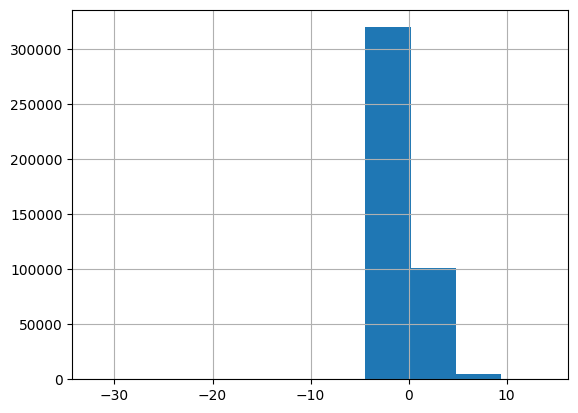

In [147]:
status_df['tempo_curso'] = (
    (status_df['ano'] - status_df['ano_ingresso_final']) * 2 +
    (status_df['periodo'] - status_df['periodo_ingresso_final'])
)
status_df['tempo_curso'].hist(bins=10)

In [149]:
status_df['tempo_curso'] = status_df['tempo_curso'].clip(lower=0)
status_df['tempo_curso'].describe()

count    426753.000000
mean          0.511996
std           1.099044
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          14.000000
Name: tempo_curso, dtype: float64

In [150]:
status_df.groupby('id_discente')['ano'].nunique().describe(percentiles=[0.95])

count    33433.000000
mean         1.234140
std          0.617774
min          1.000000
50%          1.000000
95%          3.000000
max          8.000000
Name: ano, dtype: float64

A variável de tempo no curso foi descartada, pois a maior parte dos alunos possui poucos períodos observados no dataset, resultando em baixa variabilidade da variável (concentração em zero). Isso inviabiliza sua utilização como proxy confiável de progressão acadêmica.

In [90]:
# agora a variável de queda de desempenho da média, ou seja, delta_media = media_t - media_t-1
status_df = status_df.sort_values(['id_discente', 'ano', 'periodo'])

media_periodo = (
    status_df.groupby(['id_discente', 'ano', 'periodo'])['media_geral']
    .mean()
    .reset_index()
)
media_periodo

,id_discente,ano,periodo,media_geral
0,0000636998178194,2023,2,NaN
1,0000716919028109,2023,1,NaN
2,0000860108029840,2023,2,NaN
3,0001011803301454,2020,1,NaN
4,0001198849824106,2024,1,NaN
...,...,...,...,...
48442,9999343060834420,2023,1,NaN
48443,9999762968997087,2023,2,NaN
48444,9999790736642315,2023,1,NaN
48445,9999792683829512,2023,2,NaN


In [103]:
media_periodo[~media_periodo['media_geral'].isna()].head(15)

,id_discente,ano,periodo,media_geral
22,0004463581058113,2018,2,7.65
23,0004463581058113,2019,1,7.65
24,0004463581058113,2019,2,7.65
25,0004463581058113,2020,1,7.65
26,0004463581058113,2020,2,7.65
27,0004463581058113,2021,1,7.65
28,0004463581058113,2023,1,7.65
39,0008069574245491,2021,1,3.22
40,0008069574245491,2021,2,3.22
44,0009279654760790,2021,2,0.00


In [104]:
status_df.groupby('id_discente')['media_geral'].nunique().describe()

count    33433.00000
mean         0.21057
std          0.40772
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: media_geral, dtype: float64

In [101]:
media_periodo.query('id_discente == "9997641405967411"')

,id_discente,ano,periodo,media_geral
48431,9997641405967411,2019,1,8.79
48432,9997641405967411,2019,2,8.79
48433,9997641405967411,2020,1,8.79


In [ ]:
discentes.media_geral

0       0.93
1       0.00
2       9.05
3       9.00
4       7.27
        ... 
7700    0.00
7701    8.47
7702    0.00
7703    9.21
7704    3.79
Name: media_geral, Length: 7705, dtype: float64

pelo visto aqui temos um problema, a media_geral é acumulada historicamente e não é por período, então não vamos conseguir fazer isso dessa maneira pois o ideal era por ano e período, vamos ter que pular isso

In [108]:
status_df['situacao'].value_counts()

situacao
APROVADO               318849
CANCELADO               32931
REPROVADO               25175
EXCLUIDA                14846
REP. MEDIA E FALTA      12986
MATRICULADO             11770
TRANCADO                 4560
APROVEITADO              4197
DISPENSADO                470
REP. FALTA                411
DESISTENCIA               322
TRANSFERIDO               221
INDEFERIDO                  8
APROV. C/ DISTINÇÃO         7
Name: count, dtype: int64

In [123]:
# vamos fazer com if >= 2 trancamentos recentes -> target = 1
status_df['is_trancado'] = (
    status_df['situacao'] == 'TRANCADO'
).astype(int)
tranc_por_periodo = (
    status_df.groupby(['id_discente', 'ano', 'periodo'])['is_trancado']
    .sum()
    .reset_index()
)
tranc_por_periodo = tranc_por_periodo.sort_values(
    ['id_discente', 'ano', 'periodo']
)
tranc_por_periodo['teve_trancamento'] = (
    tranc_por_periodo['is_trancado'] > 0
).astype(int)
display(tranc_por_periodo[tranc_por_periodo['is_trancado']>1])
display(tranc_por_periodo['is_trancado'].value_counts())
display(tranc_por_periodo['is_trancado'].describe())

,id_discente,ano,periodo,is_trancado,teve_trancamento
183,0040348132666707,2021,2,10,1
200,0043364866422040,2021,2,6,1
245,0052630129581584,2024,1,3,1
301,0065049618935785,2018,1,8,1
449,0102425183423668,2021,2,7,1
...,...,...,...,...,...
47749,9835963258946827,2015,1,2,1
48008,9896866872046613,2018,2,2,1
48089,9916381196282829,2018,2,4,1
48139,9929651895973281,2017,2,3,1


is_trancado
0     47679
1       156
6        76
3        74
2        70
7        61
11       50
8        47
4        45
5        44
10       36
9        34
12       30
19       15
18       13
20        7
13        5
17        3
16        2
Name: count, dtype: int64

count    48447.000000
mean         0.094123
std          0.937735
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         20.000000
Name: is_trancado, dtype: float64

In [ ]:
tranc_por_periodo['tranc_rolling_3'] = (
    tranc_por_periodo.groupby('id_discente')['teve_trancamento']
    .rolling(3)
    .sum()
    .reset_index(level=0, drop=True)
)

tranc_por_periodo['target_trancamento'] = (
    tranc_por_periodo['tranc_rolling_3'] >= 2
).astype(int)
tranc_por_periodo['target_trancamento'].value_counts()



target_trancamento
0    48367
1       80
Name: count, dtype: int64

In [130]:
tranc_por_periodo['target_trancamento'] = (
    tranc_por_periodo['teve_trancamento']
).astype(int)
tranc_por_periodo['target_trancamento'].value_counts()


target_trancamento
0    47679
1      768
Name: count, dtype: int64

## Target de Trancamento e Features Temporais

A variável `situacao` foi utilizada para identificar episódios de trancamento acadêmico (`TRANCADO`). Inicialmente, foi testada uma abordagem mais restritiva, definindo o target como alunos com dois ou mais trancamentos em períodos recentes (janela móvel). No entanto, essa estratégia resultou em uma proporção extremamente baixa de casos positivos (< 0.2%), tornando o problema inadequado para modelagem supervisionada devido ao forte desbalanceamento.

Dessa forma, optou-se por uma definição mais simples e robusta:

- **Target (`target_trancamento`)**:
  - Valor 1 se o aluno apresentou pelo menos um trancamento no período
  - Valor 0 caso contrário

Essa abordagem aumenta significativamente a quantidade de exemplos positivos, permitindo melhor aprendizado pelo modelo.

Além disso, para capturar o comportamento temporal do aluno, foram mantidas features derivadas:

- **`tranc_rolling_3`**:
  - Número de períodos com trancamento nos últimos 3 períodos
  - Representa recorrência de trancamentos

Essa separação entre target simples e features temporais permite que o modelo aprenda padrões mais complexos (como persistência de trancamentos) sem comprometer a qualidade do target.

**Resumo da estratégia:**
- Target: evento direto e frequente (trancamento no período)
- Features: histórico e recorrência de comportamento

Essa abordagem equilibra interpretabilidade, robustez e capacidade preditiva.

agora vamos trazer tudo para um df por periodo e criar uma target de risco

In [156]:
# df base
df_periodo = (
    status_df.groupby(['id_discente', 'ano', 'periodo'])
    .first()
    .reset_index()
)
# colocando as targets no mesmo nível
percentil_periodo = (
    status_df.groupby(['id_discente', 'ano', 'periodo'])['target_percentil_media']
    .max()
    .reset_index()
)
reprov_periodo = reprov_periodo[['id_discente', 'ano', 'periodo', 'target_reprov']]
tranc_periodo = tranc_por_periodo[['id_discente', 'ano', 'periodo', 'target_trancamento']]

# garantindo tipagens
for df in [df_periodo, percentil_periodo, reprov_periodo, tranc_periodo]:
    df['ano'] = df['ano'].astype(int)
    df['periodo'] = df['periodo'].astype(int)

df_periodo = df_periodo.merge(
    percentil_periodo,
    on=['id_discente', 'ano', 'periodo'],
    how='left'
)

df_periodo = df_periodo.merge(
    reprov_periodo,
    on=['id_discente', 'ano', 'periodo'],
    how='left'
)

df_periodo = df_periodo.merge(
    tranc_periodo,
    on=['id_discente', 'ano', 'periodo'],
    how='left'
)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17008\213866311.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ano'] = df['ano'].astype(int)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_17008\213866311.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['periodo'] = df['periodo'].astype(int)


In [158]:
df_periodo.duplicated(['id_discente', 'ano', 'periodo']).sum()

np.int64(0)

In [76]:
# from unidecode import unidecode
df = status_df.copy()
df = df.dropna(subset=['status_discente'])

# Definir o Y
df["evasao"] = (df["status_discente"] == "CANCELADO").astype(int)

# Criar variaveis
df["idade_ingresso"] = df["ano_ingresso"] - df["ano_nascimento"]
df["carga_restante"] = df["ch_pendente"]
df["ingresso_recente"] = (df["ano_ingresso"] >= 2020).astype(int)


# X da dimensão discente
x1 = (df
.dropna(subset=['status_discente', 'idade_ingresso'])
.drop_duplicates(subset='id_discente', ignore_index=True)
.merge(aprovdisc)
.astype({"id_curso": int})
)


# Funções auxiliares
def gera_dummies(df, colname, map=None):
    if map is not None:
        df[colname] = df[colname].map(map)
    else:
        df[colname] = df[colname].astype(str).str.lower()
    return pd.get_dummies(df, columns=[colname], drop_first=True, dtype=int)
    
# Dummies de Sexo
x1 = gera_dummies(x1, 'sexo',  {"F": "feminino", "M": "masculino"})
x1 = gera_dummies(x1, 'estado_civil',  {"Solteiro(a)": "solteiro", "Casado(a)": "casado", "Outro": "outro"})
for col in ['raca_declarada', 'faixa_renda_familiar', 'id_curso']:
    x1 = gera_dummies(x1, col)

# # 'quantidade_membros_familia', 'progresso_curso', 'carga_restante': tem muito NA
colunas_base = ['evasao', 'ano_ingresso', 'periodo_ingresso', 
               'idade_ingresso',  'aprov_disciplinas', 'ingresso_recente']

# pegar automaticamente as dummies
colunas_dummies = [
    c for c in x1.columns
    if c.startswith("sexo_")
    or c.startswith("estado_civil_")
    or c.startswith("raca_declarada_")
    or c.startswith("faixa_renda_familiar_")
    or c.startswith("id_curso_")
]

data = x1[colunas_base+colunas_dummies]

# =========================================================
#  DIVISÃO TREINO / TESTE TEMPORAL
# =========================================================
CUTOFF = 2020

# Excluir os dois ultimos anos de ingressantes para evitar problema do tempo de curso
ANO_ATUAL = data.ano_ingresso.max()
data = data[data["ano_ingresso"] <= ANO_ATUAL - 2]

train = data[data["ano_ingresso"] <= CUTOFF].copy()
test  = data[data["ano_ingresso"] > CUTOFF].copy()

print("proporção treino:", len(train) / len(data))
print("proporção teste :", len(test) / len(data))

print("evasão treino:", train["evasao"].mean())
print("evasão teste :", test["evasao"].mean())

proporção treino: 0.5991448423303046
proporção teste : 0.40085515766969537
evasão treino: 0.5495093666369313
evasão teste : 0.4697777777777778


In [77]:
# Bloco. X, y
X_train = train.drop(['evasao'], axis=1)
y_train = train['evasao']
X_test = test.drop(['evasao'], axis=1)
y_test = test['evasao']

In [78]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo
cv = StratifiedKFold(n_splits = 5, shuffle=True, random_state=1)

# (A) LOGIT
pipe_logit = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=1))
    ])

param_grid = {"model__C": [0.01, 0.1, 1, 10],
              "model__penalty": ["l1", "l2"]}
grid_logit = GridSearchCV(pipe_logit, param_grid=param_grid, cv=cv)
grid_logit.fit(X_train, y_train)


c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https

,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [79]:
print("Melhores parâmetros modelo Logit:", grid_logit.best_params_)
print("Melhor Scores de Performance:", grid_logit.best_score_)

Melhores parâmetros modelo Logit: {'model__C': 10, 'model__penalty': 'l2'}
Melhor Scores de Performance: 0.9110963701974104


In [80]:
# (B) Random Forest
pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=1, class_weight="balanced"))
    ])

param_grid = {"model__n_estimators": [200, 400],
              "model__max_depth": [4, 8, None],
              "model__min_samples_leaf": [1, 5, 10]}
grid_rf = GridSearchCV(pipe_rf, param_grid=param_grid, cv=cv)
grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'model__max_depth': [4, 8, ...], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [200, 400]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [81]:
print("Melhores parâmetros modelo RF:", grid_rf.best_params_)
print("Melhor Scores de Performance:", grid_rf.best_score_)

Melhores parâmetros modelo RF: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Melhor Scores de Performance: 0.916746267600651


In [82]:
# Bloco de seleção do melhor modelo entre as diferentes especificações
if np.round(grid_logit.best_score_,2) >= np.round(grid_rf.best_score_,2):
    melhor_modelo = grid_logit.best_estimator_
    nome_modelo = "Regressão Logística"
else:
    melhor_modelo = grid_rf.best_estimator_
    nome_modelo = "Floresta Aleatória"

print(nome_modelo)

# Definir o Cutoff da classificação: por padrão é usado 0.5 ou 50%
# Definir do threshold de forma dinâmica
prob_train = melhor_modelo.predict_proba(X_train)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_train, prob_train)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]
print("Melhor Threshold:", best_threshold)

Floresta Aleatória
Melhor Threshold: 0.585


In [83]:
# Avaliação no Teste
prob_test = melhor_modelo.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= best_threshold).astype(int)
matriz_confusao = confusion_matrix(y_test, pred_test)
print(roc_auc_score(y_test, pred_test))
print(classification_report(y_test, pred_test))

0.8608153363875206
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1193
           1       0.81      0.91      0.86      1057

    accuracy                           0.86      2250
   macro avg       0.86      0.86      0.86      2250
weighted avg       0.86      0.86      0.86      2250



In [84]:
# A importância dos atributos
if nome_modelo=="Regressão Logística":
    coefs = melhor_modelo.named_steps["model"].coef_[0]
    importancia = pd.DataFrame({"variavel": X_train.columns, 
    "coeficiente": coefs, "coef_abs": np.abs(coef)}).sort_values("coef_abs", ascending=False)
else:
    importancias = melhor_modelo.named_steps["model"].feature_importances_
    importancia = pd.DataFrame({"variavel": X_train.columns, 
    "importancia": importancias}).sort_values("importancia", ascending=False)

print(importancia)

                        variavel  importancia
3              aprov_disciplinas     0.676756
2                 idade_ingresso     0.076499
15      faixa_renda_familiar_nan     0.045523
0                   ano_ingresso     0.037960
14   faixa_renda_familiar_ate_1k     0.020690
5                 sexo_masculino     0.014586
1               periodo_ingresso     0.014101
9           raca_declarada_negra     0.012562
23              id_curso_1997022     0.009297
7          estado_civil_solteiro     0.008094
8   raca_declarada_nao_informado     0.007875
4               ingresso_recente     0.007118
6             estado_civil_outro     0.007110
25              id_curso_1997026     0.007045
19              id_curso_1958832     0.006842
18              id_curso_1958830     0.006591
36              id_curso_2663867     0.005159
35              id_curso_2558681     0.004947
20              id_curso_1996990     0.004107
22              id_curso_1997021     0.003538
51              id_curso_3926060  

In [85]:
# Salvar o modelo
import pickle
output = {
    "modelo": melhor_modelo, 
    "threshold": float(best_threshold),
    "features": X_train.columns.tolist(),
    "nome_modelo": nome_modelo,
    "importancia": importancia
}
with open("modelo_evasao.pkl", "wb") as file:
    pickle.dump(output, file)